# Step 3 — RFM features

One row per customer: **recency** (days since last purchase), **frequency** (distinct invoices), and **monetary** (gross total spend), each scored 1–5. Built on the customer-attributed sales. Reasoning recorded in `results/rfm/tables/rfm_notes.txt`.

In [1]:
# Setup: run from the project root so the data directory and results/
# resolve exactly as they do in main.py, and the step modules import.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import pandas as pd
from IPython.display import Image, display

DATA_DIR = "kaggle_customer_intelligence"


In [2]:
# Small loaders for the artefacts the earlier steps saved.
def load_sales():
    p = f"{DATA_DIR}/clean_sales.parquet"
    try:
        return pd.read_parquet(p)
    except Exception:
        df = pd.read_csv(f"{DATA_DIR}/clean_sales.csv", parse_dates=["InvoiceDate"])
        df["CustomerID"] = df["CustomerID"].astype("Int64")
        return df

def load_customer_sales():
    s = load_sales()
    return s[s["CustomerID"].notna()].reset_index(drop=True)


In [3]:
from retail_rfm import RFMBuilder

customer_sales = load_customer_sales()
rfm = RFMBuilder(customer_sales).run()
rfm.save(DATA_DIR)

RFM FEATURES
Top customers by total spend:
CustomerID
18102    580987.04
14646    526751.52
14156    303069.88
14911    272252.79
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144033.37

Largest single order lines:
 Invoice  CustomerID StockCode                        Description  Quantity  Price  Revenue
  581483       16446     23843        PAPER CRAFT , LITTLE BIRDIE     80995   2.08 168469.6
  541431       12346     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04  77183.6
  497946       13902     37410 BLACK AND WHITE PAISLEY FLOWER MUG     19152   0.10   1915.2
  501534       13902     21099        SET/6 STRAWBERRY PAPER CUPS     12960   0.10   1296.0
  501534       13902     21091        SET/6 WOODLAND PAPER PLATES     12960   0.10   1296.0
  501534       13902     21085          SET/6 WOODLAND PAPER CUPS     12744   0.10   1274.4
  501534       13902     21092      SET/6 STRAWBERRY PAPER PLATES     12480   0.10 

### The two phantom orders

The run prints the largest orders before removing anything. Two invoices stand out: an 80,995-unit order (invoice 581483, ~£168k) and a 74,215-unit one (541431, ~£77k), each placed and cancelled the same day. The cancellations were removed in cleaning, so the positive sides survived and made two customers look like the biggest buyers in the data. They're dropped here, and the printout above shows them go. The genuine wholesalers below them (a £581k and a £527k customer) are real and kept.

In [4]:
rfm.rfm.head()

,recency,frequency,monetary,R,F,M,RFM_cell,RFM_sum
CustomerID,,,,,,,,
12346,530,2,169.36,1,2,1,121,4
12347,3,8,4921.53,5,4,5,545,14
12348,76,5,1658.40,3,3,4,334,10
12349,19,3,3678.69,5,3,5,535,13
12350,311,1,294.40,2,1,2,212,5


### Distributions

Recency splits the base in two: an active group near zero and a dormant group out past a year, with a bump around 12 months (the seasonal one-and-done buyers). Monetary is unusable raw, but **logs to a clean bell**, which is why segmentation clusters on log-monetary. Frequency is discrete and stays lumpy even logged.

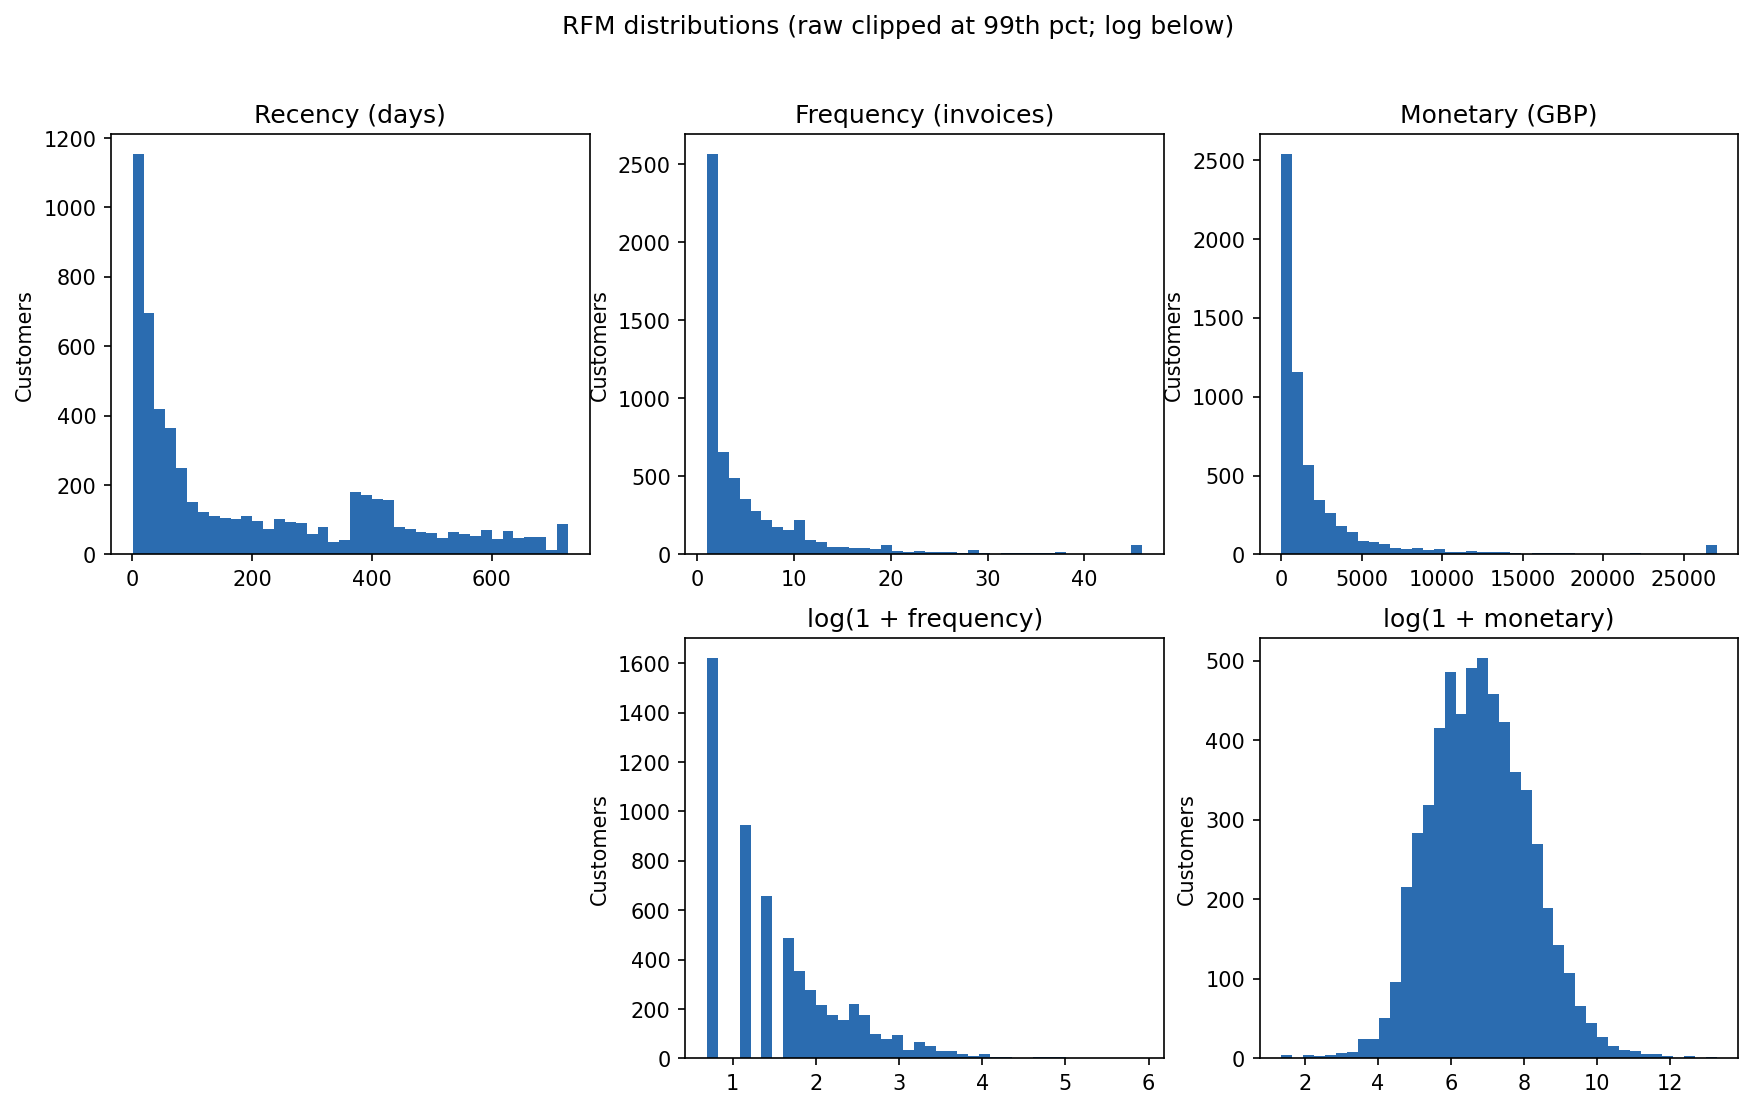

In [5]:
display(Image(filename="results/rfm/figures/rfm_distributions.png"))

### Scores

Recency and monetary use rank-based quintiles, so their score bars are even by construction. Frequency uses fixed bins (1, 2, 3–5, 6–10, 11+) because about a quarter of customers share frequency = 1, which is more than one quintile can hold. Its uneven bars are the real frequency profile, not an artefact.

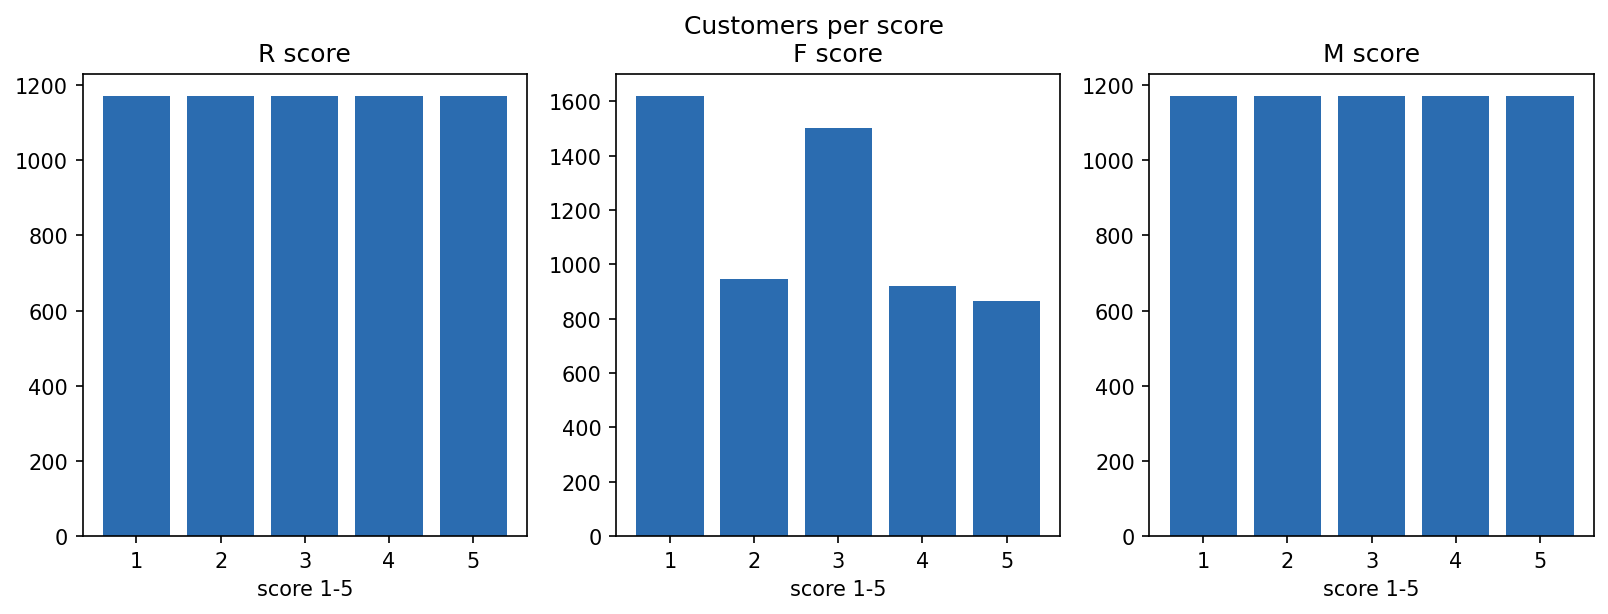

,recency,frequency,monetary
count,5852.000000,5852.000000,5852.000000
mean,200.802290,6.252905,2874.729113
std,208.544937,12.749400,14108.708367
min,1.000000,1.000000,2.900000
25%,26.000000,1.000000,339.242500
50%,96.000000,3.000000,855.580000
75%,380.000000,7.000000,2237.292500
90%,531.000000,13.000000,5374.868000
95%,624.000000,20.000000,9226.956500
99%,727.000000,46.000000,27061.386600


In [6]:
display(Image(filename="results/rfm/figures/rfm_score_counts.png"))
pd.read_csv("results/rfm/tables/rfm_stats.csv", index_col=0)

**Hands off to:** `rfm.features`, the per-customer R/F/M table, which segmentation extends with basket and variety features.